# Regression Training — Elemental Concentration Prediction

Trains and evaluates all regression models:
- **CNNRegressor** and **ResNetRegressor** (PyTorch)
- **PLSBaseline** and **RidgeBaseline** (scikit-learn)

All models predict the relative concentration of each of the 41 supported elements
from a 600-bin XRF spectrum. Targets are Dirichlet-distributed (sum to 1, sparse).

Metrics are computed **only on active elements** (ground-truth > 0) to avoid
trivial inflation from predicting 0 for absent elements.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import sys
import os

# Ensure project root is in sys.path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data.regression.generator import RegressionDataGenerator
from src.data.common.base_generator import GeneratorConfig
from src.models.regression import (
    CNNRegressor, ResNetRegressor,
    CNNRegressorV2, MLPRegressor,
    RegressionTrainer,
    PLSBaseline, RidgeBaseline,
    evaluate_all,
)

In [2]:
NUM_WORKERS = 18

## Data Generation

Using `GeneratorConfig.Presets.regression()`: high signal counts, mild Poisson noise,
fixed Bremsstrahlung background. Each sample has 2–5 active elements.

In [3]:
SEED = 42
np.random.seed(SEED)

gen = RegressionDataGenerator(seed=SEED)
config = GeneratorConfig.Presets.regression()
config.summary()

N_TRAIN, N_VAL, N_TEST = 10000, 4000, 4000

print("Generating training data...")
X_train, y_train = gen.generate_dataset(N_TRAIN, min_elements=2, max_elements=5, config=config, num_workers=NUM_WORKERS)
print("Generating validation data...")
X_val, y_val = gen.generate_dataset(N_VAL, min_elements=2, max_elements=5, config=config, num_workers=NUM_WORKERS)
print("Generating test data...")
X_test, y_test = gen.generate_dataset(N_TEST, min_elements=2, max_elements=5, config=config, num_workers=NUM_WORKERS)

# y is a DataFrame — extract numpy arrays and element names
element_names = y_train.columns.tolist()
y_train_np = y_train.values
y_val_np   = y_val.values
y_test_np  = y_test.values

print(f"\nTrain : X={X_train.shape}, y={y_train_np.shape}")
print(f"Val   : X={X_val.shape},   y={y_val_np.shape}")
print(f"Test  : X={X_test.shape},  y={y_test_np.shape}")
print(f"Elements ({len(element_names)}): {element_names[:10]} ...")

----------------------------------------
      XRF Generator Configuration       
----------------------------------------
s_counts_range      : (50000, 150000)
n_counts_range      : (1000, 5000)
b_counts_range      : (3000, 3000)
c_counts_range      : (3000, 3000)
escape_prob         : 1.0
sum_peaks_prob      : 1.0
decal_prob          : 0.0
kvp_range           : (30.0, 30.0)
angle_range         : (46.0, 46.0)
mas_range           : (9.0, 9.0)
target_materials    : ['Mo']
filters             : [('Be', 0.127), ('Air', 10.0)]
----------------------------------------
Generating training data...
Starting parallel regression generation with 18 workers...


Parallel Regression Generation: 100%|██████████| 10000/10000 [07:36<00:00, 21.90it/s]


Generating validation data...
Starting parallel regression generation with 18 workers...


Parallel Regression Generation: 100%|██████████| 4000/4000 [03:06<00:00, 21.48it/s]


Generating test data...
Starting parallel regression generation with 18 workers...


Parallel Regression Generation: 100%|██████████| 4000/4000 [03:07<00:00, 21.34it/s]



Train : X=(10000, 600), y=(10000, 41)
Val   : X=(4000, 600),   y=(4000, 41)
Test  : X=(4000, 600),  y=(4000, 41)
Elements (41): ['O', 'F', 'Na', 'Mg', 'Al', 'Si', 'P', 'S', 'Cl', 'Ar'] ...


## CNN Regressor

3-block 1D CNN with a Softmax output head (enforces sum-to-1 constraint).
Trained with `CombinedRegressionLoss` (MaskedMSE + KL-divergence).

Training:  33%|███▎      | 20/60 [00:13<00:26,  1.49it/s, train=1.0094e-01, val=1.0274e-01]


Early stopping at epoch 21


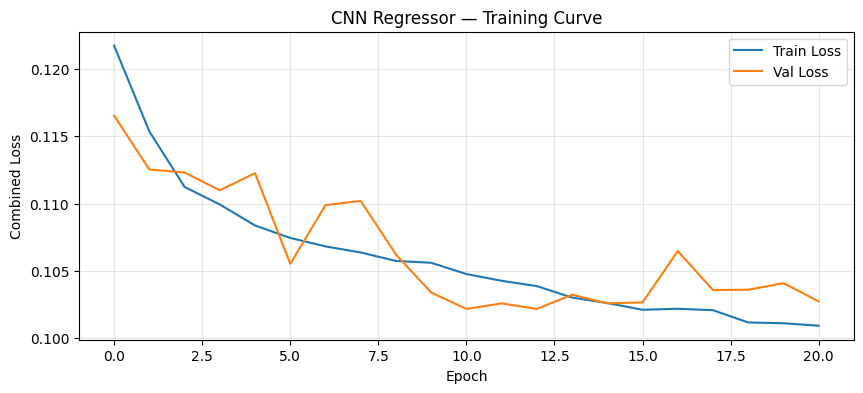

In [4]:
cnn_model = CNNRegressor(input_dim=600, n_elements=41, dropout=0.3)
cnn_trainer = RegressionTrainer(cnn_model, learning_rate=1e-3, mse_weight=1.0, kl_weight=0.0, scaler="log_minmax")

cnn_history = cnn_trainer.train(
    X_train, y_train_np,
    X_val,   y_val_np,
    epochs=60, batch_size=64, patience=10,
)

plt.figure(figsize=(10, 4))
plt.plot(cnn_history["train_loss"], label="Train Loss")
plt.plot(cnn_history["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Combined Loss")
plt.title("CNN Regressor — Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## ResNet Regressor

1D ResNet with residual blocks — better gradient flow and feature reuse,
useful when spectra have overlapping peaks.

Training:  60%|██████    | 36/60 [00:25<00:17,  1.39it/s, train=7.1703e-02, val=8.8143e-02]

Early stopping at epoch 37


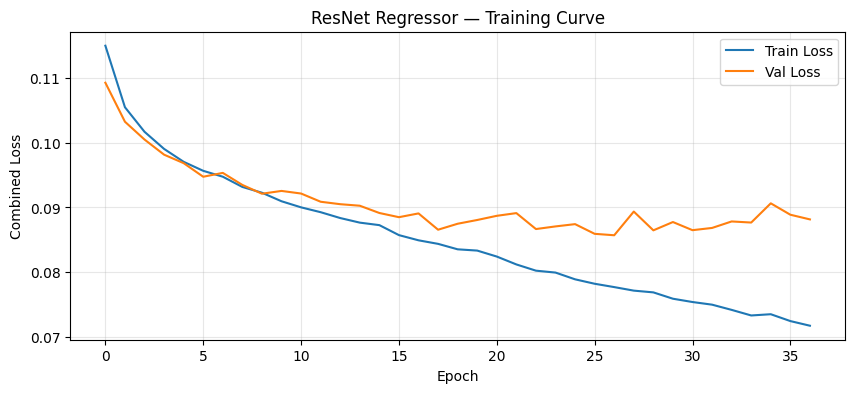

In [5]:
resnet_model = ResNetRegressor(input_dim=600, n_elements=41, dropout=0.3)
resnet_trainer = RegressionTrainer(resnet_model, learning_rate=1e-3, mse_weight=1.0, kl_weight=0.0, scaler="log_minmax")

resnet_history = resnet_trainer.train(
    X_train, y_train_np,
    X_val,   y_val_np,
    epochs=60, batch_size=64, patience=10,
)

plt.figure(figsize=(10, 4))
plt.plot(resnet_history["train_loss"], label="Train Loss")
plt.plot(resnet_history["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Combined Loss")
plt.title("ResNet Regressor — Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Baselines

Classical chemometrics baselines:
- **PLS** (n=20 components): standard XRF quantification approach
- **Ridge**: simple L2-regularized linear model, one regressor per element

Training:  88%|████████▊ | 53/60 [00:14<00:01,  3.71it/s, train=3.8688e-01, val=6.6818e-01]

Early stopping at epoch 54


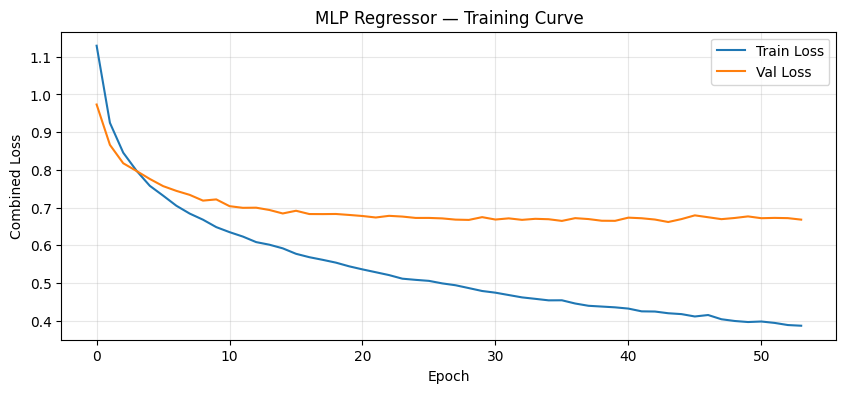

In [6]:
mlp_model = MLPRegressor()
mlp_trainer = RegressionTrainer(mlp_model, learning_rate=1e-3, scaler="log_minmax")

mlp_history = mlp_trainer.train(
    X_train, y_train_np,
    X_val,   y_val_np,
    epochs=60, batch_size=64, patience=10,
)

plt.figure(figsize=(10, 4))
plt.plot(mlp_history["train_loss"], label="Train Loss")
plt.plot(mlp_history["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Combined Loss")
plt.title("MLP Regressor — Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Training:  40%|████      | 24/60 [00:21<00:32,  1.09it/s, train=5.4633e-02, val=8.3283e-02]

Early stopping at epoch 25


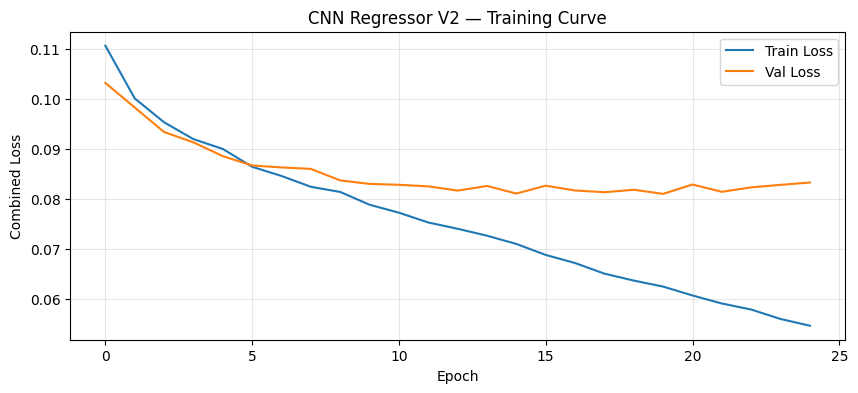

In [11]:
cnn_v2_model = CNNRegressorV2(input_dim=600, n_elements=41, dropout=0.3)
cnn_v2_trainer = RegressionTrainer(cnn_v2_model, learning_rate=1e-3, mse_weight=1.0, kl_weight=0.0, scaler="log_minmax")
cnn_v2_history = cnn_v2_trainer.train(
    X_train, y_train_np,
    X_val,   y_val_np,
    epochs=60, batch_size=64, patience=10,
)

plt.figure(figsize=(10, 4))
plt.plot(cnn_v2_history["train_loss"], label="Train Loss")
plt.plot(cnn_v2_history["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Combined Loss")
plt.title("CNN Regressor V2 — Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## MLP Regressor

Wide MLP with BatchNorm. Since PLS (a linear model) is already competitive with the CNN,
a wide non-linear MLP may capture the concentration→spectrum relationship without
losing spatial information through pooling.


=== Test Set Metrics (active elements only) ===
        masked_mae  masked_mse  masked_r2
CNN         0.2421      0.1029    -0.8902
ResNet      0.2258      0.0871    -0.5995
CNN V2      0.2163      0.0820    -0.5066
MLP         0.2167      0.0785    -0.4410
PLS         0.2264      0.0949    -0.7429
Ridge       0.2098      0.0803    -0.4741


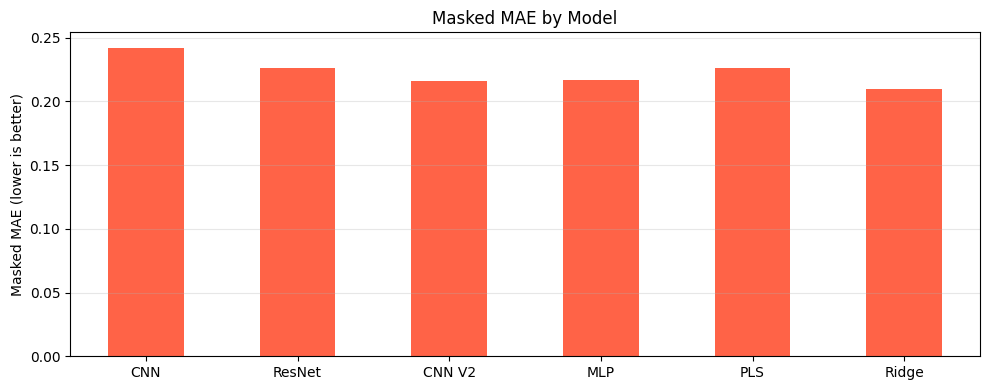

In [12]:
results = {}

results["CNN"]       = cnn_trainer.evaluate(X_test, y_test_np, element_names=element_names)
results["ResNet"]    = resnet_trainer.evaluate(X_test, y_test_np, element_names=element_names)
results["CNN V2"]    = cnn_v2_trainer.evaluate(X_test, y_test_np, element_names=element_names)
results["MLP"]       = mlp_trainer.evaluate(X_test, y_test_np, element_names=element_names)
results["PLS"]       = pls.evaluate(X_test, y_test_np)
results["Ridge"]     = ridge.evaluate(X_test, y_test_np)

summary = pd.DataFrame({
    name: {k: v for k, v in m.items() if k != "per_element_mae"}
    for name, m in results.items()
}).T

print("\n=== Test Set Metrics (active elements only) ===")
print(summary.to_string(float_format="{:.4f}".format))

summary[["masked_mae"]].plot(kind="bar", figsize=(10, 4), legend=False,
                              color=["tomato","salmon","steelblue","seagreen","goldenrod","orchid"])
plt.title("Masked MAE by Model")
plt.ylabel("Masked MAE (lower is better)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## CNN Regressor V2

Fixes three weaknesses of the original CNN:
- **AvgPool** instead of MaxPool (preserves peak amplitude)
- **No Global Average Pool** — spatial structure kept to 15 positions before flatten
- **Softmax** output instead of ReLU+normalise (no collapse when uncertain)

In [13]:
pls = PLSBaseline(n_components=20)
pls.fit(X_train, y_train_np, element_names=element_names)
print("PLS trained.")

ridge = RidgeBaseline(alpha=1.0)
ridge.fit(X_train, y_train_np, element_names=element_names)
print("Ridge trained.")

PLS trained.
Ridge trained.


## Model Comparison on Test Set

Metrics computed on active elements only (ground-truth concentration > 0).

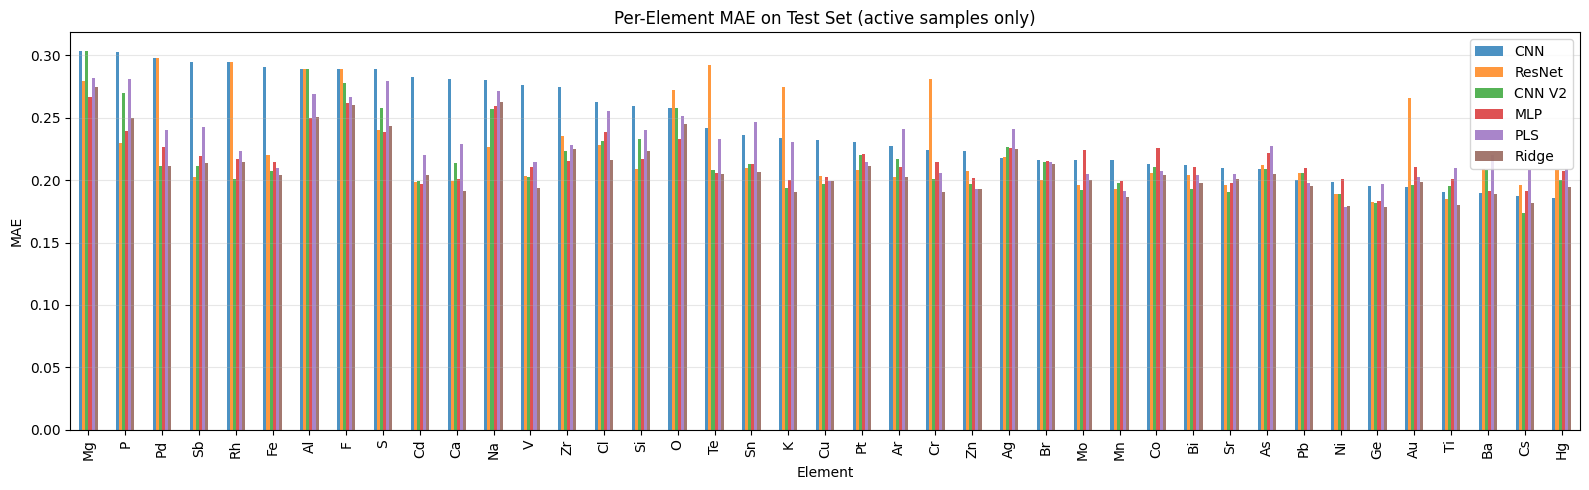


Top 5 hardest elements (CNN V2 MAE):
Mg   0.3032
P    0.2699
Pd   0.2113
Sb   0.2115
Rh   0.2007


In [14]:
per_el = pd.DataFrame({
    name: m.get("per_element_mae")
    for name, m in results.items()
    if m.get("per_element_mae") is not None
}).dropna()

per_el_sorted = per_el.sort_values("CNN", ascending=False)

ax = per_el_sorted.plot(kind="bar", figsize=(16, 5), alpha=0.8)
ax.set_title("Per-Element MAE on Test Set (active samples only)")
ax.set_ylabel("MAE")
ax.set_xlabel("Element")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 hardest elements (CNN V2 MAE):")
print(per_el_sorted["CNN V2"].head(5).to_string(float_format="{:.4f}".format))

## Prediction Visualization

For a few test samples, compare predicted vs actual concentrations.
Only active elements are shown (zero-concentration elements omitted).

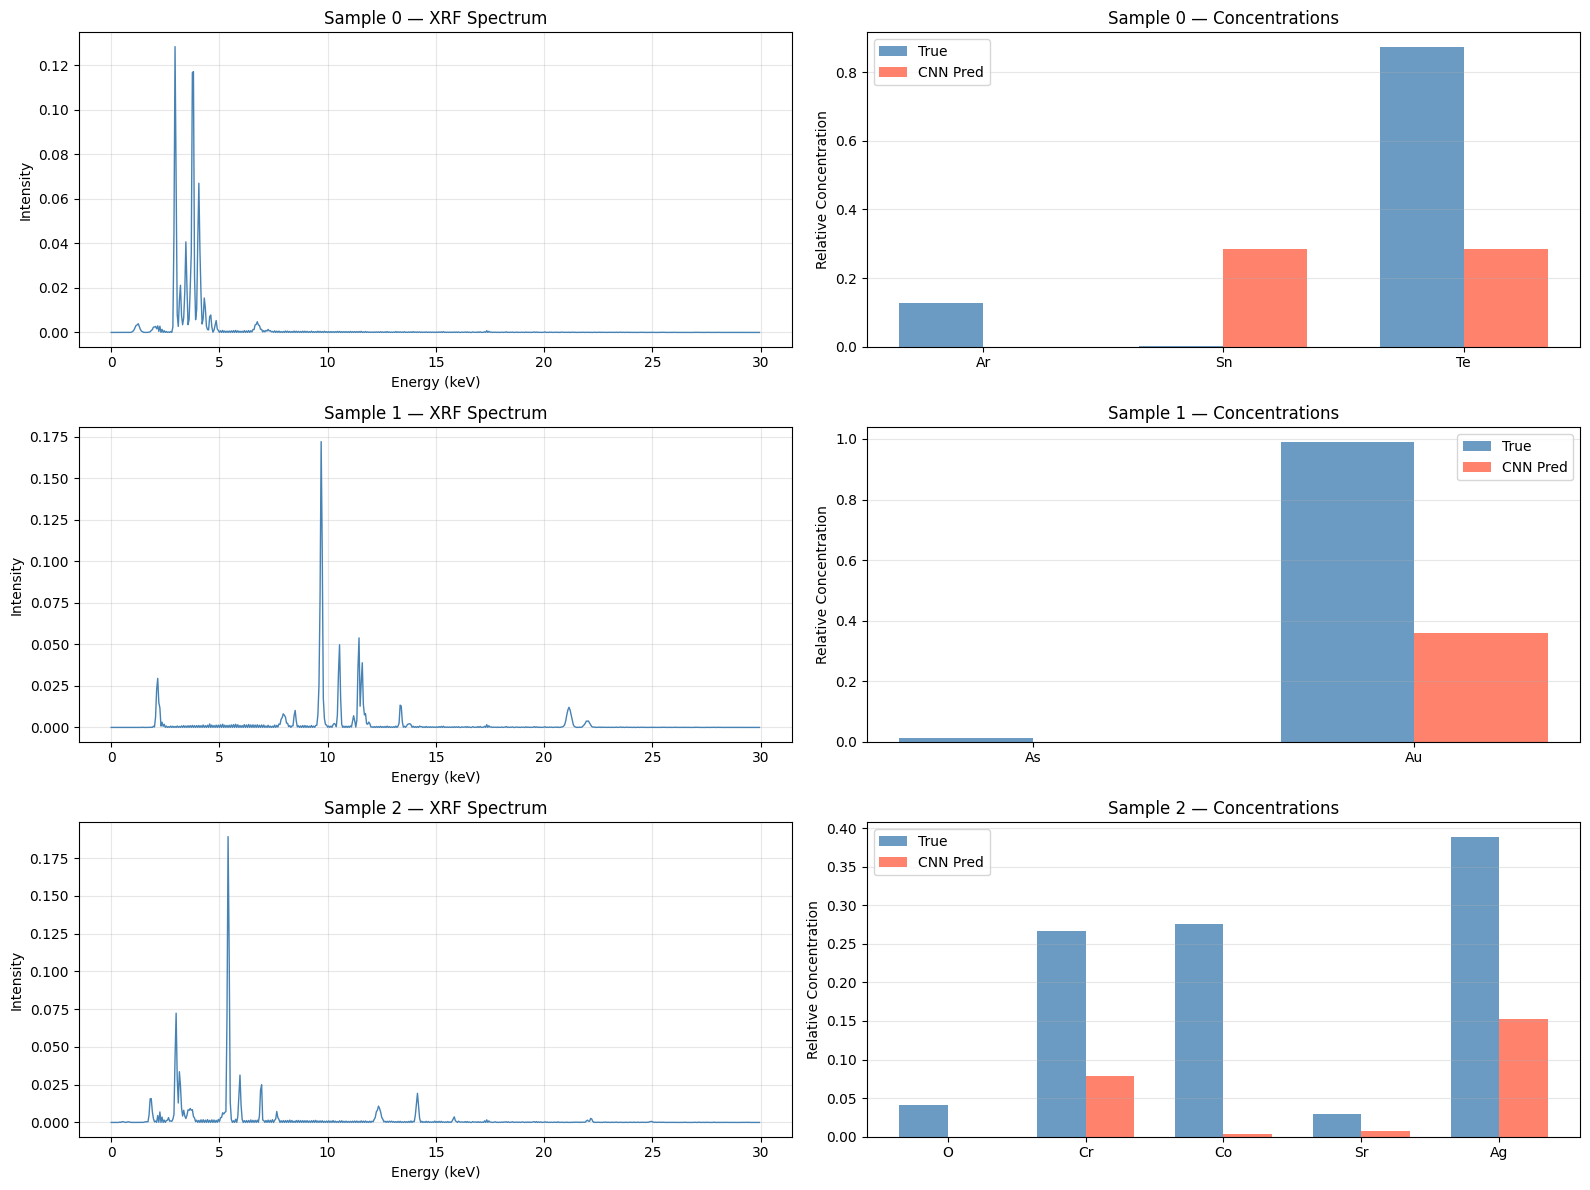

In [15]:
cnn_preds = cnn_trainer.predict(X_test)
energies  = np.arange(0, 30, 0.05)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for i in range(3):
    ax_spec = axes[i, 0]
    ax_bar  = axes[i, 1]

    # Left: input spectrum
    ax_spec.plot(energies, X_test[i], lw=1, color="steelblue")
    ax_spec.set_title(f"Sample {i} — XRF Spectrum")
    ax_spec.set_xlabel("Energy (keV)")
    ax_spec.set_ylabel("Intensity")
    ax_spec.grid(alpha=0.3)

    # Right: predicted vs true concentrations (active elements only)
    active_mask = y_test_np[i] > 0
    active_els  = [element_names[j] for j in range(41) if active_mask[j]]
    true_vals   = y_test_np[i][active_mask]
    pred_vals   = cnn_preds[i][active_mask]

    x_pos = np.arange(len(active_els))
    width = 0.35
    ax_bar.bar(x_pos - width/2, true_vals, width, label="True",      color="steelblue", alpha=0.8)
    ax_bar.bar(x_pos + width/2, pred_vals, width, label="CNN Pred",  color="tomato",    alpha=0.8)
    ax_bar.set_xticks(x_pos)
    ax_bar.set_xticklabels(active_els)
    ax_bar.set_ylabel("Relative Concentration")
    ax_bar.set_title(f"Sample {i} — Concentrations")
    ax_bar.legend()
    ax_bar.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Per-Element MAE

MAE broken down by element — averaged over all test samples where that element is active.
Elements with no active samples are shown as NaN and excluded.

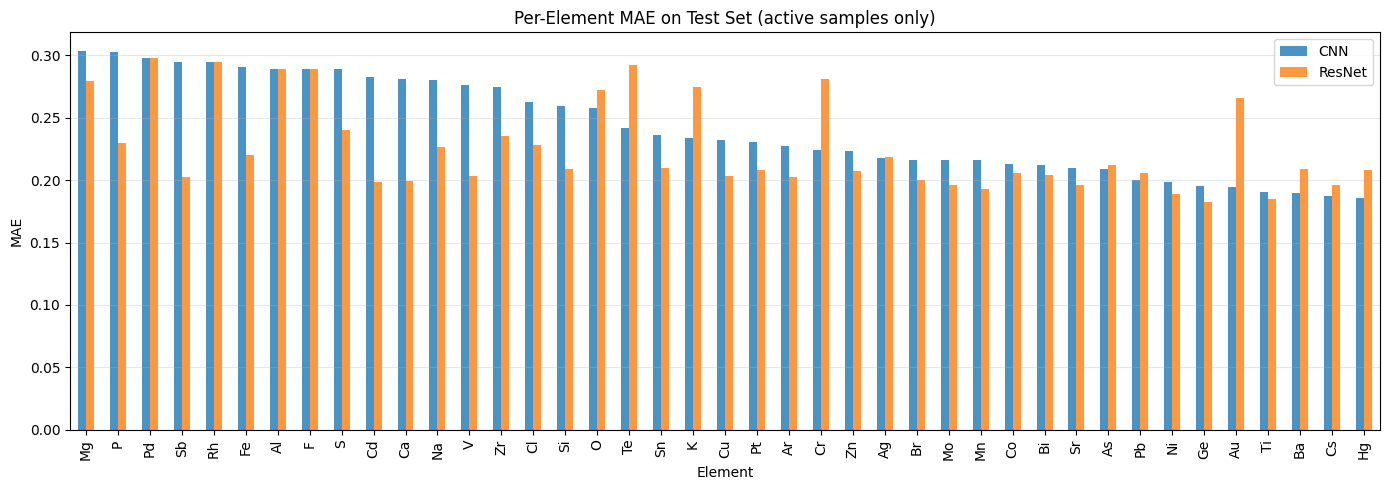


Top 5 hardest elements (CNN MAE):
Mg   0.3032
P    0.3022
Pd   0.2980
Sb   0.2947
Rh   0.2946


In [16]:
per_el_cnn    = results["CNN"].get("per_element_mae")
per_el_resnet = results["ResNet"].get("per_element_mae")

per_el_true = y_test_np[y_test_np > 0]

if per_el_cnn is not None and per_el_resnet is not None:
    per_el = pd.DataFrame({"CNN": per_el_cnn, "ResNet": per_el_resnet}).dropna()
    per_el_sorted = per_el.sort_values("CNN", ascending=False)

    ax = per_el_sorted.plot(kind="bar", figsize=(14, 5), alpha=0.8)
    ax.set_title("Per-Element MAE on Test Set (active samples only)")
    ax.set_ylabel("MAE")
    ax.set_xlabel("Element")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nTop 5 hardest elements (CNN MAE):")
    print(per_el_sorted["CNN"].head(5).to_string(float_format="{:.4f}".format))